# Spaceship Titanic - Business Understanding & Exploratory Data Analysis

## Objective

The objective of this notebook is to understand the dataset before performing any preprocessing or model training.

This notebook focuses on:

- Understanding the business problem.
- Inspecting the dataset.
- Assessing data quality.
- Exploring the target variable.
- Identifying potential issues and opportunities.
- Defining the next steps of the Machine Learning workflow.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

In [2]:
train_df = pd.read_csv("../data/raw/train.csv")
test_df = pd.read_csv("../data/raw/test.csv")

In [3]:
train_df.shape
train_df.head()
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


<Axes: xlabel='Transported', ylabel='count'>

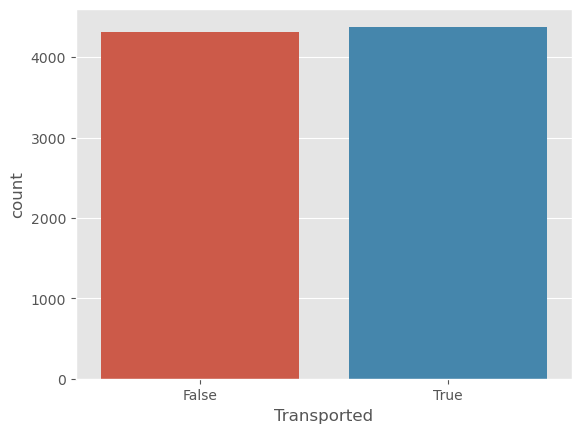

In [4]:
train_df["Transported"].value_counts()
sns.countplot(data=train_df, x="Transported")

In [5]:
missing = (
    train_df
    .isna()
    .sum()
    .sort_values(ascending=False)
)

missing = missing[missing > 0]

<Axes: xlabel='HomePlanet', ylabel='count'>

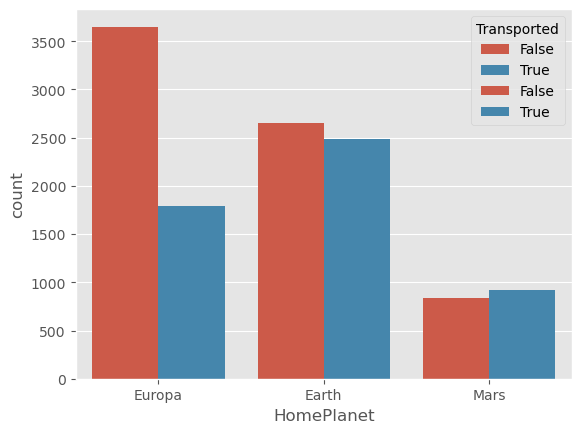

In [6]:
sns.countplot(
    data=train_df,
    x="CryoSleep",
    hue="Transported"
)

sns.countplot(
    data=train_df,
    x="HomePlanet",
    hue="Transported"
)

In [7]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.features.preprocessing import get_feature_types, build_preprocessor

X = train_df.drop(columns="Transported")

numeric_features, categorical_features = get_feature_types(X)

print(numeric_features)
print(categorical_features)

['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'VIP', 'Name']


In [8]:
from src.config import TARGET_COLUMN
from src.models.train import  build_baseline_pipeline
X = train_df.drop(columns=TARGET_COLUMN)
y = train_df[TARGET_COLUMN]

numeric_features, categorical_features = get_feature_types(X)

preprocessor = build_preprocessor(
    numeric_features,
    categorical_features,
)

pipeline = build_baseline_pipeline(preprocessor)